In [167]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv')

In [168]:
#number of rows and columns in the data set
df.shape

(397, 7)

In [169]:
#preview the data set
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [170]:
#what are the columns in this data set
df.columns

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [171]:
#rename column with missing name
df = df.rename(columns = {'Unnamed: 0': 'employee_number'})
df.head()

,employee_number,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [172]:
#is there any missing data? (no)
df.isnull().sum().sum().sum().sum().sum().sum().sum()

np.int64(0)

In [173]:
#what are the summary stats for all of the salaries?
df ['salary'].describe()

,salary
count,397.000000
mean,113706.458438
std,30289.038695
min,57800.000000
25%,91000.000000
50%,107300.000000
75%,134185.000000
max,231545.000000


In [174]:
#what is the median salary for all of the salaries?
df ['salary'].median()

107300.0

In [175]:
#what are the different discpline categories
df.groupby (['discipline'])['employee_number'].count()

,employee_number
discipline,
A,181
B,216


In [176]:
#does one discipline category generally pay higher than the other? Which has a higher median salary?

discipline_a = df[['salary','discipline']] [df['discipline'] == 'A']['salary'].median()
discipline_b = df[['salary','discipline']] [df['discipline'] == 'B']['salary'].median()


print(f"Discipline A median salary is'{discipline_a}' and Discipline B median salary is {discipline_b} ")

Discipline A median salary is'104350.0' and Discipline B median salary is 113018.5 


In [177]:
#how many male and female employees
df.groupby(['sex'])['employee_number'].count()




,employee_number
sex,
Female,39
Male,358


In [178]:
#how many male and how many female employees, and what are their ranks
df[['sex', 'rank', 'employee_number' ]].groupby(['sex', 'rank']).count()


employee_number
sex    rank                      
Female AssocProf               10
       AsstProf                11
       Prof                    18
Male   AssocProf               54
       AsstProf                56
       Prof                   248

In [179]:
#what are the summary stats for female employee salaries?

df_female = df[df['sex'] == 'Female']
df_female['salary'].describe()


,salary
count,39.000000
mean,101002.410256
std,25952.127317
min,62884.000000
25%,77250.000000
50%,103750.000000
75%,117002.500000
max,161101.000000


In [180]:
#median female salary
df_female ['salary'].median()

103750.0

In [181]:
#what are the summary stats for male employee salaries

df_male = df[df['sex'] == 'Male']
df_male['salary'].describe()

,salary
count,358.000000
mean,115090.418994
std,30436.927344
min,57800.000000
25%,92000.000000
50%,108043.000000
75%,134863.750000
max,231545.000000


In [182]:
#median male salary
df_male ['salary'].median()

108043.0

In [183]:
#calculate the pay gap between male and female median salaries

df_f = df_female ['salary'].median()
df_m = df_male ['salary'].median()

df_m - df_f

4293.0

In [184]:
#Could the pay gap be attributed to a larger percentage of males working in the higher paid Discipline B?
#What is the discipline breakdown by gender?

result = (
    df.groupby(['sex', 'discipline'])['employee_number']
      .count()
      .reset_index(name='count')
)

result['percentage'] = (
    result['count'] /
    result.groupby('sex')['count'].transform('sum')
    * 100
)

result

#Interestingly, it's almost exactly the same percentage split between Discipline A and B for
#both males and females, so discipline is an unlikely contributing factor to the pay gap.

,sex,discipline,count,percentage
0,Female,A,18,46.153846
1,Female,B,21,53.846154
2,Male,A,163,45.530726
3,Male,B,195,54.469274


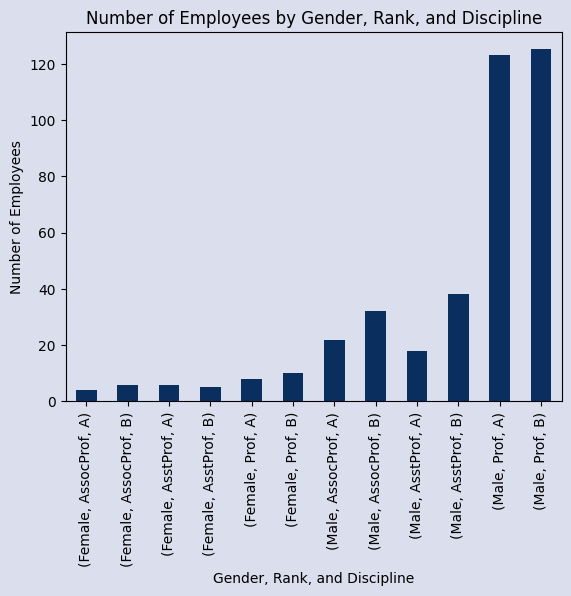

In [185]:
#bar chart of number of employees by gender, rank, and discipline, overview of staff makeup
colors = ['#0a2f5e']
ax = df.groupby(['sex','rank', 'discipline'])['employee_number'].count().plot.bar(stacked = 'true',#
title = 'Number of Employees by Gender, Rank, and Discipline', ylabel = 'Number of Employees', xlabel = 'Gender, Rank, and Discipline', color = colors)
ax.set_facecolor('#dadeed')
ax.figure.set_facecolor('#dadeed');

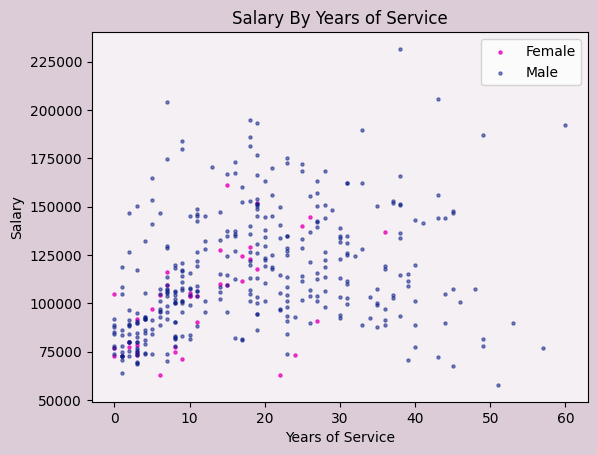

In [201]:
plt.figure(facecolor='#dbccd8') # outer color

# Female
plt.scatter(
    df[df['sex'] == 'Female']['yrs.service'],
    df[df['sex'] == 'Female']['salary'],
    s=5,
    alpha=0.75,
    color='#e805bb',
    label='Female'
)

# Male
plt.scatter(
    df[df['sex'] == 'Male']['yrs.service'],
    df[df['sex'] == 'Male']['salary'],
    s=5,
    alpha=0.5,
    color='#071c87',
    label='Male'
)

ax = plt.gca()

ax.set_facecolor('#f5f0f3') # inner color

plt.xlabel('Years of Service')
plt.ylabel('Salary')
plt.title('Salary By Years of Service')

plt.legend()

plt.show()

Conclusions:
Since the percentage split of females working in Discipline A vs Discipline B is more or less the same as for males, Discipline is not a likely contributing factor to the pay gap. It would be interesting to dig deeper to compare more closely rank, discipline, years since PhD and number of years of service to further analyze this gap.

There are a far greater number of male vs. female employees, indicating an overall potential gender bias in the system.
When looking at salary by years of service, most of the employees fall between 0 and 20 years of service, with pay concentrated between 75k-125k. Salaries appear to rise until about 20 years of service, where it appears to plateau. The highest paid workers also have the longest number of years of service, and are all male. The greatest number of female workers appear between 0-20 years of service, yet none of them are among the highest earning workers in this range.